<a href="https://colab.research.google.com/github/rubendariodiazvitals-crypto/EstadisticaVerano2026/blob/main/Practica003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problema 3
A menudo, quienes hacen la contabilidad de costos estiman los gastos generales con base en el nivel de producción. En Standard Knitting Co. han reunido información acerca de los gastos generales y las unidades producidas en diferentes plantas.

| Gastos generales | 191 | 170 | 272 | 155 | 280 | 173 | 234 | 116 | 153 | 178 |
|------------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| Unidades        |  40 |  42 |  53 |  35 |  56 |  39 |  48 |  30 |  37 |  40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "gastos_generales": [191,170,272,155,280,173,234,116,153,178],
    "unidades": [40,42,53,35,56,39,48,30,37,40],
})

df

,gastos_generales,unidades
0,191,40
1,170,42
2,272,53
3,155,35
4,280,56
5,173,39
6,234,48
7,116,30
8,153,37
9,178,40


1.   **Establesca una variable dependiente ($Y$) y una variable independiente ($X$)**

+ $Y$: son los gastos generales
+ $X$: son las unidades

In [ ]:
# Y: gastos generales
# X: unidades

X = df['gastos_generales']
Y = df['unidades']

2.   **Realice un diagrama de dispersión para estos datos.**

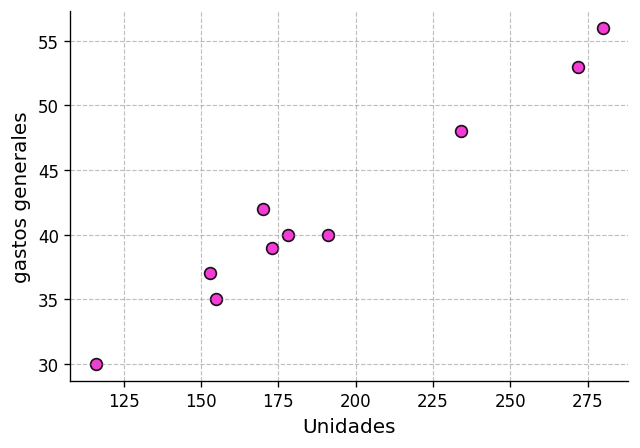

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Unidades', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'gastos generales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

3. **¿Los datos soportan la suposición de linealidad?**

Sí, porque entre más aumentan los gastos generales, las unidades aumentan, es decir hay más producción.

4. **Calcule el coeficiente de correlación e interprete el resultado.**

In [ ]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlaciòn: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlaciòn:  0.9835
valor_p:  0.0000


El coeficiente de correlación es $r=0.9835$, este valor indica que la correlación es fuerte, dado que está muy cerca de 1. Además, el que sea positiva, implica que al aumentar los gastos generales ($Y$) aumenta las unidades ($X$).

5. **Calcule el coeficiente de determinación e interprete el resultado.**

In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [ ]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  96.73%


Con coeficiente de determinación de $$r^2=0.9673$$ indica que con las ausencias estoy justificando en un $96.73\%$ la variabilidad en los salarios. Por lo que el modelo puede tener una buena capacidad de predicción.

6. **Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión**

In [ ]:
modelo.params

,0
const,13.360132
gastos_generales,0.149011


La ecuación de la recta es:

$$
\hat{y}=13.360132+0.149011X
$$

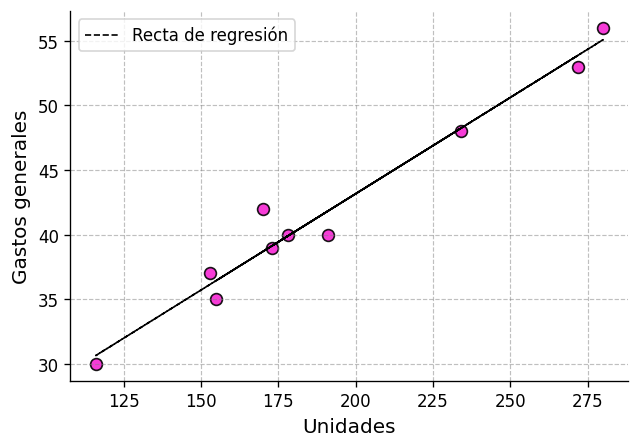

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Unidades', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Gastos generales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

7. **Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

La recta tiene la forma:

$$\hat{y}=b_0+b_1X$$



In [ ]:
modelo.conf_int(alpha=0.05)

,0,1
const,8.920794,17.799471
gastos_generales,0.126675,0.171347


El verdadero $b_0$ está entre $8.920794$ y $0.126675$ con una confianza del 95%. Esto indica que una persona sin ausencias ($X=0$) tiene una categoría de salario ($Y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre $0.171347$ y $17.799471$ con un 95% de confianza. Dado que dentre de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre 0.172989 y 0.350638 en la categoría de salario.

8. **Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [ ]:
residuales = modelo.resid

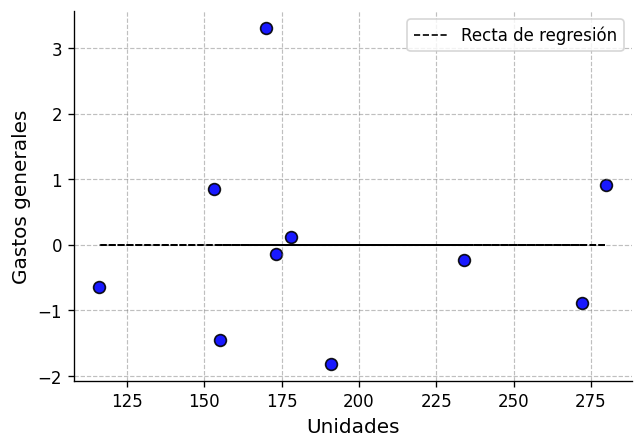

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Unidades', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Gastos generales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Para los supuestos:


+ Linealidad: Parece que sí, porque van sobre la recta, pero pued ser confuso por la cantidad de datos.
+ Normalidad: Sí cumple con la normalidad, porque hay puntos cerca de la línea.
+ Homoscedasticidad: Sí cumple con la homoscedasticidad, porque los puntos estan dispersos.
+ Independencia: Sí cumple, porque son diferentes unidades.

9. **Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.30963893537419923


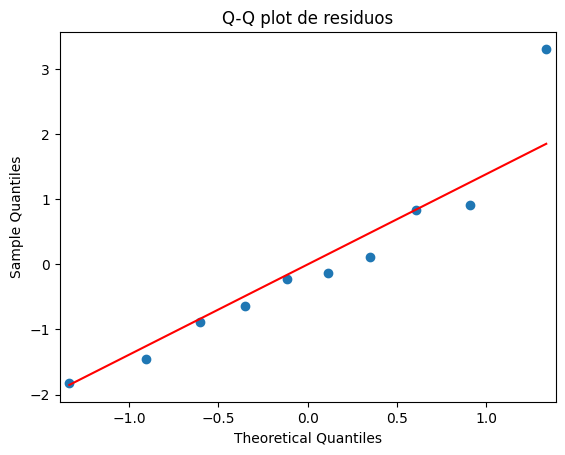

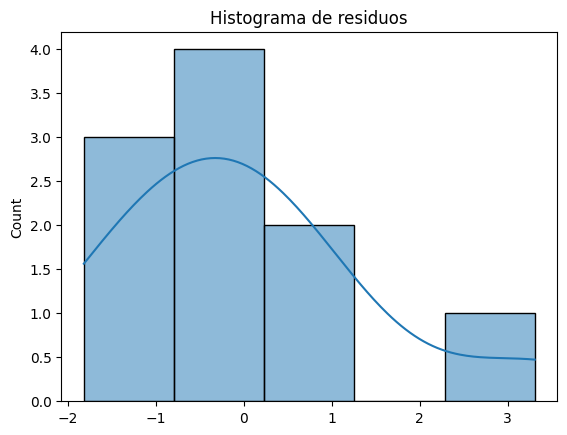

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

10. **Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.6267



11. **Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

Si el modelo cumple con todos los supuestos, es confiable para interpolación.

In [ ]:
# mínimo unidades: 30
# máximo unidades: 56

# interpolar, valores de x entre 30 y 56

# interpolar
y_25 = modelo.predict([1, 25])
y_32 = modelo.predict([1, 32])

print(f"Para x = 25, y =  {y_25[0]: 0.4f}")
print(f"Para x = 32, y =  {y_32[0]: 0.4f}")

Para x = 25, y =   17.0854
Para x = 32, y =   18.1285


La extrapolación siempre debe hacerse con cuidado, aunque cumpla con todos los supuestos.

In [ ]:
# mínimo unidades: 30
# máximo unidades: 56

# Extrapolar, valores de x que no estén entre 30 y 56

y_10 = modelo.predict([[1, 10]])

print(f"Para x = 10, y =  {y_10[0]: 0.4f}")

Para x = 10, y =   14.8502


Con 10 unidades se espera que el nivel de produción aumenten los gastos generales de 14. Este valor se obtuvo por medio de extrapolación, por lo que se toma con reservas.

12. **Realice una tabla ANOVA e interprete el resultado.**

In [ ]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''gastos_generales ~ unidades''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
unidades,1.0,24778.042517,24778.042517,236.669535,3.167080e-07
Residual,8.0,837.557483,104.694685,NaN,NaN


No hay correlación porque el valor-p de $3.167079738329314e-07$ es mayor a un nivel de significancia $\alpha=0.05$.

En los residuales del anova se puede ver la diferencia entre el valor real observado y el valor predicho por el modelo (la media de su respectivo grupo).